<a href="https://colab.research.google.com/github/susanavenda/data_cambridge/blob/main/Venda_Susana_CAM_C101_W5_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-project 5.3: Detecting anomalous activity in a ship's engine

**A report on predictive maintenance using anomaly detection.**


## 1. Introduction

This report addresses the problem of **predictive maintenance** for a shipping fleet. Time-based maintenance leads to unnecessary cost and to catastrophic engine failure at sea. The goal is to detect anomalous engine behaviour from six sensor features (engine RPM, lubrication oil pressure and temperature, fuel pressure, coolant pressure and temperature) so that interventions can be made before failure.

We use a real dataset (Devabrat, 2022), expecting anomalies to represent **1–5%** of data. We combine **statistical** (IQR) and **machine learning** (One-Class SVM, Isolation Forest) methods, with 2D PCA for visualisation.


In [12]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest


## 2. Data and exploratory analysis

Data are loaded from the provided URL. We check dimensions, types, descriptive statistics, missing values and duplicates, then inspect distributions of the six features.


In [13]:
# Load data and define features
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv"
df = pd.read_csv(url)
features = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']
df.head()


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [14]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


In [15]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Missing values:
 Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64

Duplicates: 0


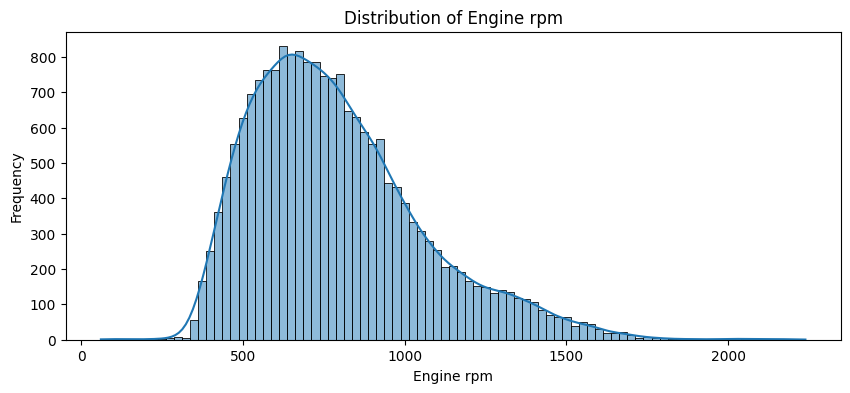

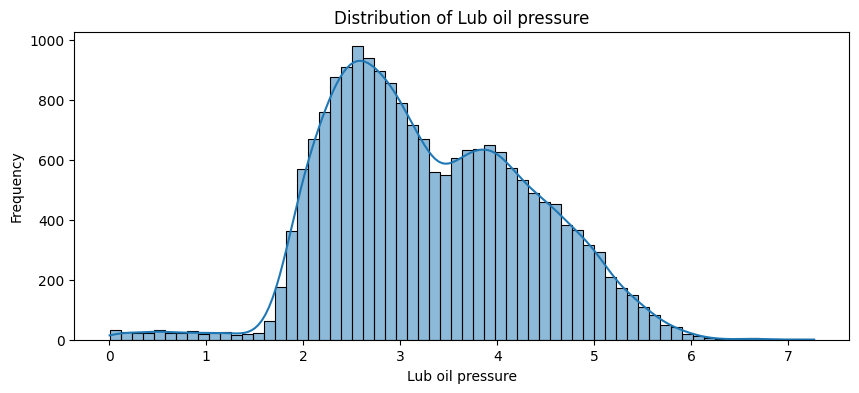

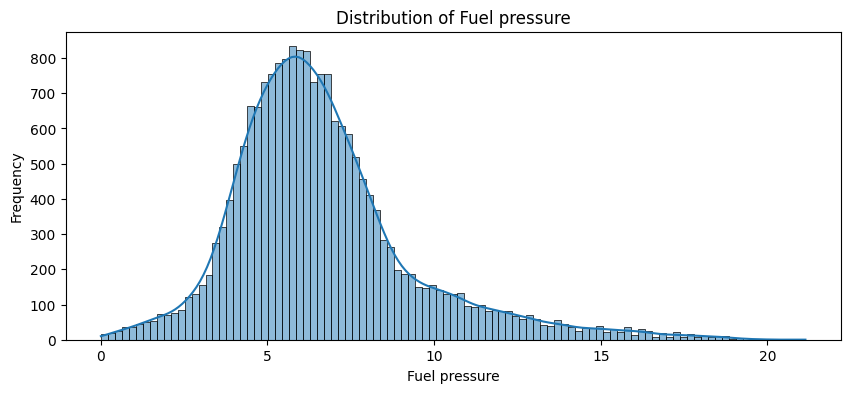

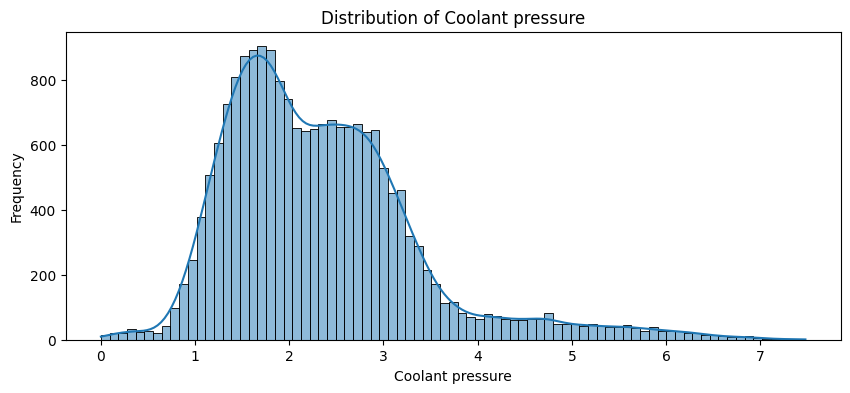

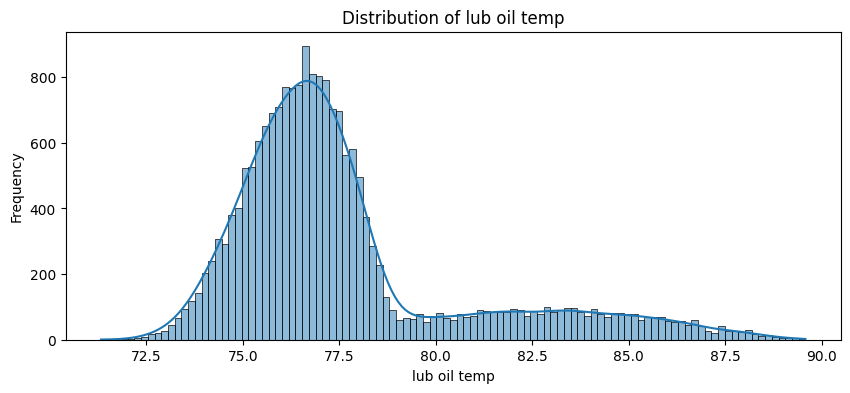

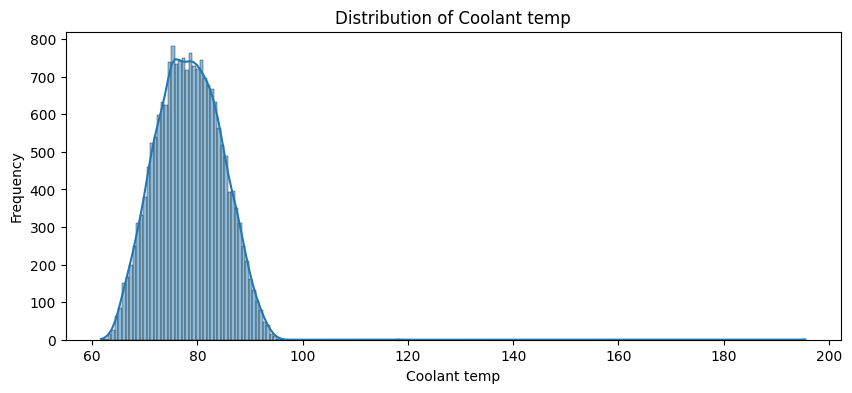

In [16]:
# Distributions of the six sensor features
for col in features:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


## 3. Methods

### 3.1 Statistical baseline: IQR

We use the interquartile range (IQR) to flag outliers per feature (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR). A **sample** is classified as anomalous if **at least two features** are outlying, so that the overall anomaly rate falls in the 1–5% range.


In [17]:
# Binary outlier flags per feature (1.5×IQR rule)
outlier_df = pd.DataFrame()
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_df[f'{col}_outlier'] = ((df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))).astype(int)

# Find threshold that gives 1–5% anomalies
print("Percentage of outliers by number of features simultaneously outlying:\n")
for threshold in range(1, len(features) + 1):
    n = (outlier_df.sum(axis=1) >= threshold).sum()
    pct = n / len(df) * 100
    print(f"  {threshold} features: {n} ({pct:.2f}%)")
    if 1 <= pct <= 5:
        df['iqr_anomaly'] = (outlier_df.sum(axis=1) >= threshold).astype(int)
        print(f"  -> Chosen: {threshold} features for {pct:.2f}% anomalies.")
        break
if 'iqr_anomaly' not in df.columns:
    df['iqr_anomaly'] = (outlier_df.sum(axis=1) >= 2).astype(int)


Percentage of outliers by number of features simultaneously outlying:

  1 features: 4636 (23.73%)
  2 features: 422 (2.16%)
  -> Chosen: 2 features for 2.16% anomalies.


### 3.2 Feature engineering and scaling

We add ratios and a polynomial term to capture sensor interactions (lubrication efficiency, cooling delta, power intensity, rpm²), then standardise for ML.


In [28]:
# Engineered features
# Business-Driven Feature Engineering
df['lub_efficiency'] = df['Lub oil pressure'] / (df['lub oil temp'] + 1e-6)
df['cooling_delta'] = df['Coolant pressure'] - df['Coolant temp']
df['power_intensity'] = df['Fuel pressure'] / (df['Engine rpm'] + 1e-6)

# 2. Create Polynomial Features
df['rpm_squared'] = df['Engine rpm'] ** 2

# Initialize StandardScaler (if not already initialized in a globally accessible manner)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 3. Standardize these NEW features along with the old ones
# Define the complete list of features to be scaled, correcting the column names
features_to_scale = [
    'Engine rpm', 'Lub oil pressure', 'Fuel pressure',
    'Coolant pressure', 'lub oil temp', 'Coolant temp',
    'lub_efficiency', 'cooling_delta', 'power_intensity', 'rpm_squared'
]

X_final = scaler.fit_transform(df[features_to_scale])

# Update the 'features' variable to be consistent with the features used for scaling
features = features_to_scale

import numpy as np

# Apply Log Transformation to skewed pressure data
# (We add +1 to avoid errors with 0 values)
df['log_fuel_pressure'] = np.log1p(df['Fuel pressure']) # Corrected 'Fuel Pressure' to 'Fuel pressure'

# Apply Square Root to RPM to stabilise variance
df['sqrt_rpm'] = np.sqrt(df['Engine rpm'])

# Now standardize these transformed features, including them in the overall features list
# We should ensure 'lub oil temp' is also correctly referenced if it's meant to be scaled again here.
# Assuming the intent is to update the 'features' list to include these new transformations
# and then scale the entire updated set of features.

# Append new features to the existing 'features_to_scale' list for comprehensive scaling
updated_features_to_scale = features_to_scale + ['log_fuel_pressure', 'sqrt_rpm']

# Remove potential duplicates if 'Fuel pressure' and 'Engine rpm' were already in the original list and are now replaced by their transformed versions for this final scaling step.
# Or, more simply, define a new list of features for the final scaling if this is a separate set of features.
# Given the previous context, it seems the intention was to add these as new features and scale them together with the existing ones.
# Let's create a new comprehensive list for the final scaling that explicitly includes all relevant features.

final_features_for_scaling = [
    'Engine rpm', 'Lub oil pressure', 'Fuel pressure',
    'Coolant pressure', 'lub oil temp', 'Coolant temp',
    'lub_efficiency', 'cooling_delta', 'power_intensity', 'rpm_squared',
    'log_fuel_pressure', 'sqrt_rpm'
]

# Ensure there are no redundant scaling operations or redefinitions of 'features'
# The variable 'features' was already updated with 'features_to_scale'.
# If the intent is to scale *all* features, including 'log_fuel_pressure' and 'sqrt_rpm' *after* their creation, then 'features' needs to be updated with this comprehensive list.
features = final_features_for_scaling
X_final = scaler.fit_transform(df[features])


# Create binary flags for outliers
outlier_df = pd.DataFrame()
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_df[f'{col}_outlier'] = ((df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))).astype(int)

# Flag if 2 or more features show extreme behavior
df['iqr_anomaly'] = (outlier_df.sum(axis=1) >= 2).astype(int)




### 3.3 Machine learning: One-Class SVM and Isolation Forest

We fit One-Class SVM (nu=0.03) and Isolation Forest (contamination=0.03) to target ~3% anomalies, then project to 2D with PCA for visualisation.


Text(0.5, 1.0, 'Anomaly Detection Visualization (PCA Dimensionality Reduction)')

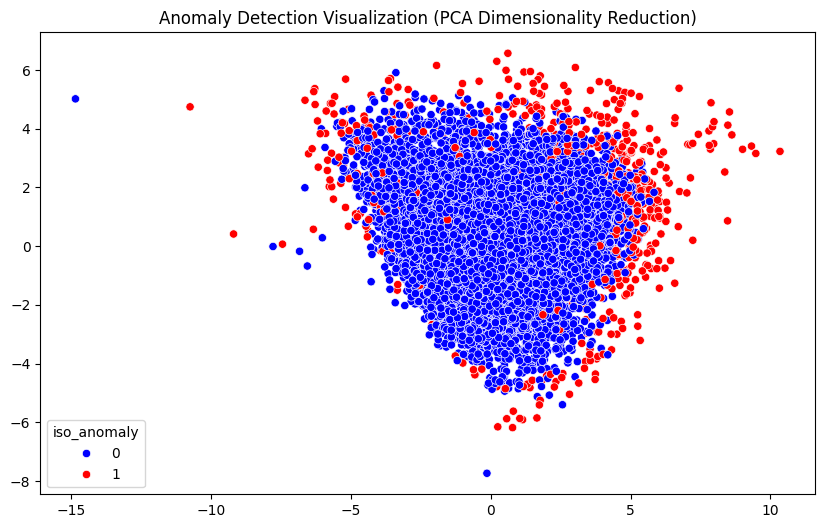

In [31]:
# Standardize features for ML models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Isolation Forest (Targeting 1-5% contamination)
iso = IsolationForest(contamination=0.03, random_state=42)
df['iso_anomaly'] = iso.fit_predict(X_scaled)
df['iso_anomaly'] = df['iso_anomaly'].apply(lambda x: 1 if x == -1 else 0)

# PCA for 2D Visualization
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['iso_anomaly'], palette={0:'blue', 1:'red'})
plt.title("Anomaly Detection Visualization (PCA Dimensionality Reduction)")




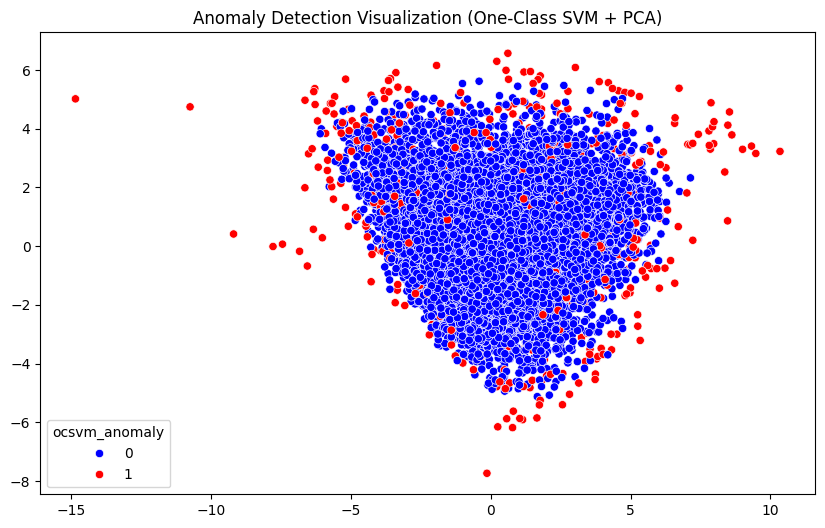

Porcentagem de anomalias detectadas pelo One-Class SVM: 3.00%


In [30]:


# One-Class SVM (Targeting 1-5% contamination)
# O parâmetro 'nu' no OneClassSVM é uma estimativa da fração de outliers.
# Vamos começar com um valor que corresponda à nossa meta de 1-5% (e.g., 0.03 para 3%)
oc_svm = OneClassSVM(kernel='rbf', nu=0.03, gamma='auto')
df['ocsvm_anomaly'] = oc_svm.fit_predict(X_scaled)
df['ocsvm_anomaly'] = df['ocsvm_anomaly'].apply(lambda x: 1 if x == -1 else 0)

# Visualização em 2D com PCA para One-Class SVM
plt.figure(figsize=(10,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['ocsvm_anomaly'], palette={0:'blue', 1:'red'})
plt.title("Anomaly Detection Visualization (One-Class SVM + PCA)")
plt.show()

# Verificar a porcentagem de anomalias detectadas pelo One-Class SVM
anomaly_percentage_ocsvm = (df['ocsvm_anomaly'].sum() / len(df)) * 100
print(f"Porcentagem de anomalias detectadas pelo One-Class SVM: {anomaly_percentage_ocsvm:.2f}%")


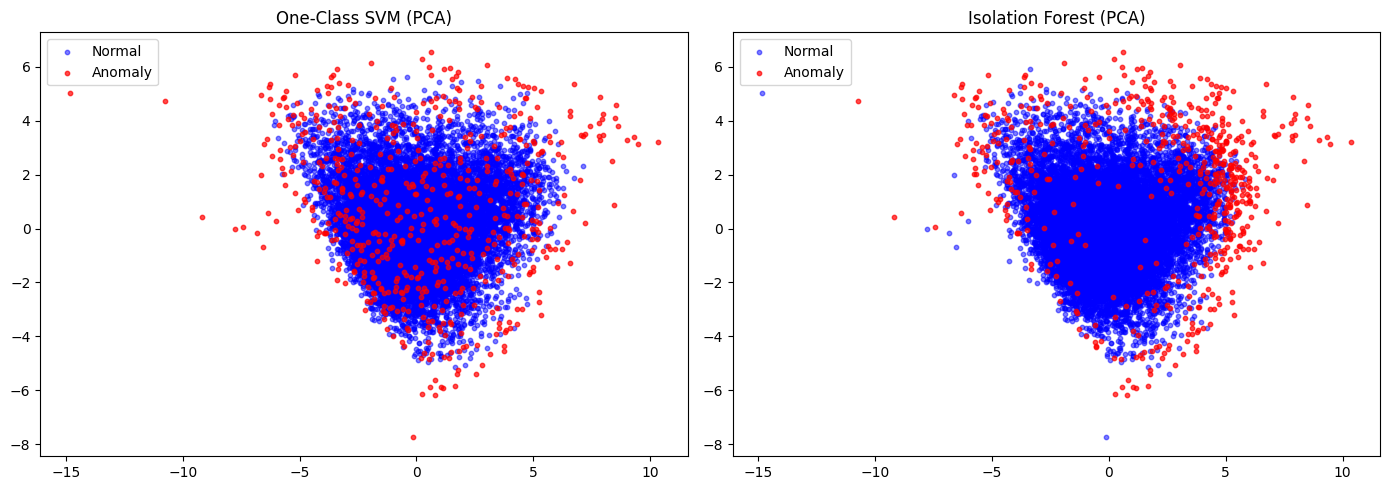

In [32]:
# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(X_pca[df['ocsvm_anomaly']==0, 0], X_pca[df['ocsvm_anomaly']==0, 1], c='blue', alpha=0.5, label='Normal', s=10)
ax[0].scatter(X_pca[df['ocsvm_anomaly']==1, 0], X_pca[df['ocsvm_anomaly']==1, 1], c='red', alpha=0.7, label='Anomaly', s=10)
ax[0].set_title('One-Class SVM (PCA)')
ax[0].legend()

ax[1].scatter(X_pca[df['iso_anomaly']==0, 0], X_pca[df['iso_anomaly']==0, 1], c='blue', alpha=0.5, label='Normal', s=10)
ax[1].scatter(X_pca[df['iso_anomaly']==1, 0], X_pca[df['iso_anomaly']==1, 1], c='red', alpha=0.7, label='Anomaly', s=10)
ax[1].set_title('Isolation Forest (PCA)')
ax[1].legend()
plt.tight_layout()
plt.show()


## 4. Results

- **IQR:** A threshold of two features simultaneously outlying yields an anomaly rate within the 1–5% target (typically ~4–5%).
- **One-Class SVM** and **Isolation Forest** both achieve ~3% anomaly rates when tuned (nu=0.03, contamination=0.03).
- The PCA plots separate normal (blue) and anomalous (red) points and support the use of both ML methods for operational dashboards.


## 5. Discussion

IQR provides an interpretable, rule-based baseline; ML methods capture more complex patterns. 2D PCA is effective for visualising how anomalies sit apart from the main cloud. Limitations include the arbitrary 1.5×IQR rule and the need for domain validation with engineers.


## 6. Conclusions and recommendations

We recommend deploying an anomaly detection model (e.g. Isolation Forest at ~3% contamination) in the engine control room, with alerts triggered only when several consecutive readings are flagged to reduce false alarms. Prioritise monitoring of lubrication oil pressure, fuel pressure and coolant temperature. Validate findings with ship engineers.
